# ----------------------------- Business Analysis Problems -----------------------------

### Importing important packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## Importing cleaned datasets

In [2]:
# ============================================================
# LOAD CLEANED DATA -- previously saved in pickle file
# ============================================================

cleaned_data = pd.read_pickle(
    "EuroEats_cleaned_data.pkl"
)

customers = cleaned_data["customers"]
restaurants = cleaned_data["restaurants"]
menu_items = cleaned_data["menu_items"]
drivers = cleaned_data["drivers"]
orders = cleaned_data["orders"]
order_items = cleaned_data["order_items"]
deliveries = cleaned_data["deliveries"]
payments = cleaned_data["payments"]
reviews = cleaned_data["reviews"]

print("Cleaned EuroEats data loaded successfully.")

Cleaned EuroEats data loaded successfully.


# Business problem solutions: 

temperature_c                -0.025135
pickup_delay_minutes          0.286579
restaurant_wait_minutes       0.345346
distance_km                   0.744830
estimated_delivery_minutes    0.916527
Name: actual_delivery_minutes, dtype: float64


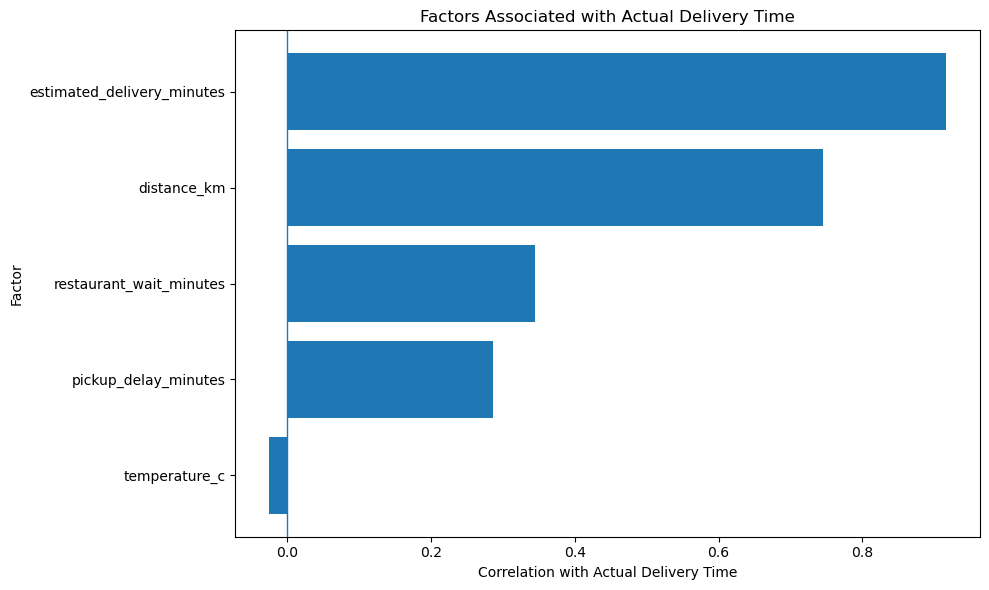

In [3]:
# ============================================================
# BUSINESS QUESTION 1
# What actually drives delivery time the most, and how big is
# each effect in practice?
#
# Chart: Correlation bar chart
# ============================================================

delivery_numeric = deliveries[
    [
        "distance_km",
        "temperature_c",
        "pickup_delay_minutes",
        "restaurant_wait_minutes",
        "estimated_delivery_minutes",
        "actual_delivery_minutes"
    ]
].copy()

correlation = (
    delivery_numeric
    .corr()["actual_delivery_minutes"]
    .drop("actual_delivery_minutes")
    .sort_values()
)

print(correlation)

plt.figure(figsize=(10, 6))

plt.barh(
    correlation.index,
    correlation.values
)

plt.xlabel("Correlation with Actual Delivery Time")
plt.ylabel("Factor")
plt.title("Factors Associated with Actual Delivery Time")

plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

        country          city  total_deliveries  avg_delivery_minutes  \
0       Austria        Vienna                33             52.745455   
37       Sweden     Stockholm                59             51.677966   
19       Greece  Thessaloniki                15             48.386667   
23        Italy         Turin                16             47.243750   
13      Germany        Berlin                78             46.394872   
24  Netherlands     Amsterdam                49             45.202041   
4       Czechia        Prague                22             44.640909   
22        Italy          Rome                60             44.580000   
2       Belgium      Brussels                42             43.547619   
18       Greece        Athens                23             43.378261   
25  Netherlands     The Hague                19             43.126316   
11       France         Paris                48             43.118750   
17      Germany        Munich                37    

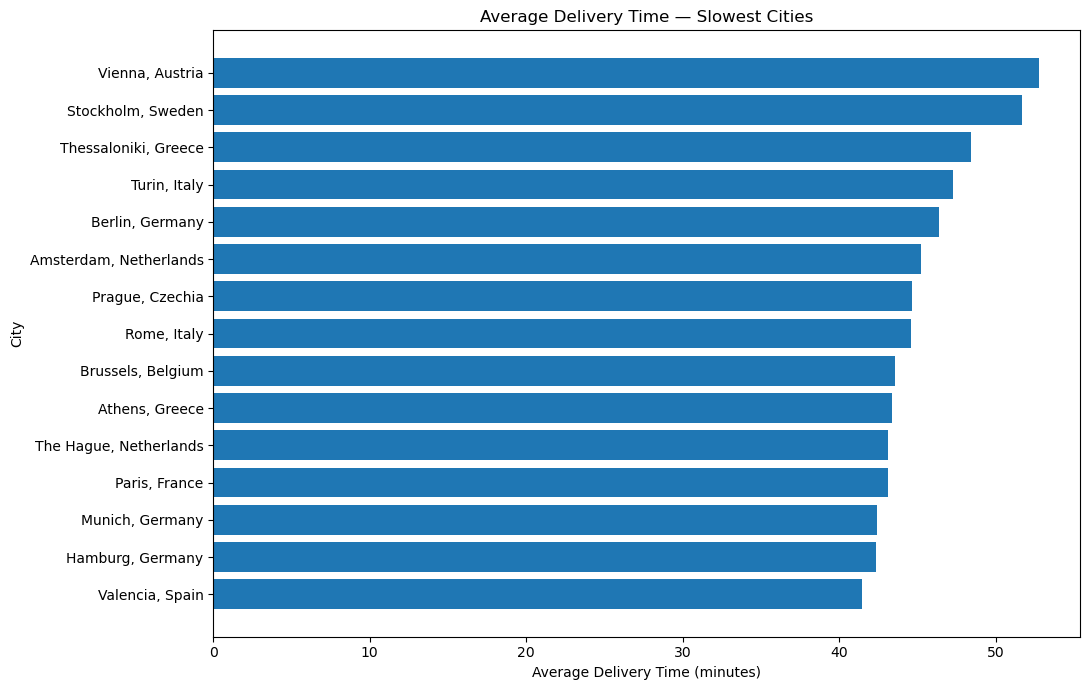

In [4]:
# ============================================================
# BUSINESS QUESTION 2
# Are certain countries or cities consistently slower to
# deliver than others, and what might explain it?
#
# Chart: Average delivery time by city
# ============================================================

delivery_location = (
    deliveries[
        [
            "order_id",
            "actual_delivery_minutes",
            "distance_km",
            "pickup_delay_minutes",
            "restaurant_wait_minutes"
        ]
    ]
    .merge(
        orders[["order_id", "restaurant_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            ["restaurant_id", "country", "city"]
        ],
        on="restaurant_id",
        how="left"
    )
)

city_performance = (
    delivery_location
    .groupby(["country", "city"])
    .agg(
        total_deliveries=("order_id", "count"),
        avg_delivery_minutes=("actual_delivery_minutes", "mean"),
        avg_distance_km=("distance_km", "mean"),
        avg_pickup_delay=("pickup_delay_minutes", "mean"),
        avg_restaurant_wait=("restaurant_wait_minutes", "mean")
    )
    .reset_index()
    .sort_values("avg_delivery_minutes", ascending=False)
)

print(city_performance)

# Top 15 slowest cities
chart_data = city_performance.head(15).copy()

chart_data["location"] = (
    chart_data["city"]
    + ", "
    + chart_data["country"]
)

plt.figure(figsize=(11, 7))

plt.barh(
    chart_data["location"][::-1],
    chart_data["avg_delivery_minutes"][::-1]
)

plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("City")
plt.title("Average Delivery Time — Slowest Cities")

plt.tight_layout()
plt.show()

  weather_condition  total_deliveries  avg_delivery_minutes  \
3              Snow                28             47.453571   
2              Rain               259             43.137838   
0             Clear               426             40.522300   
1            Cloudy               287             40.374913   

   median_delivery_minutes  
3                     40.1  
2                     37.1  
0                     36.0  
1                     36.9  


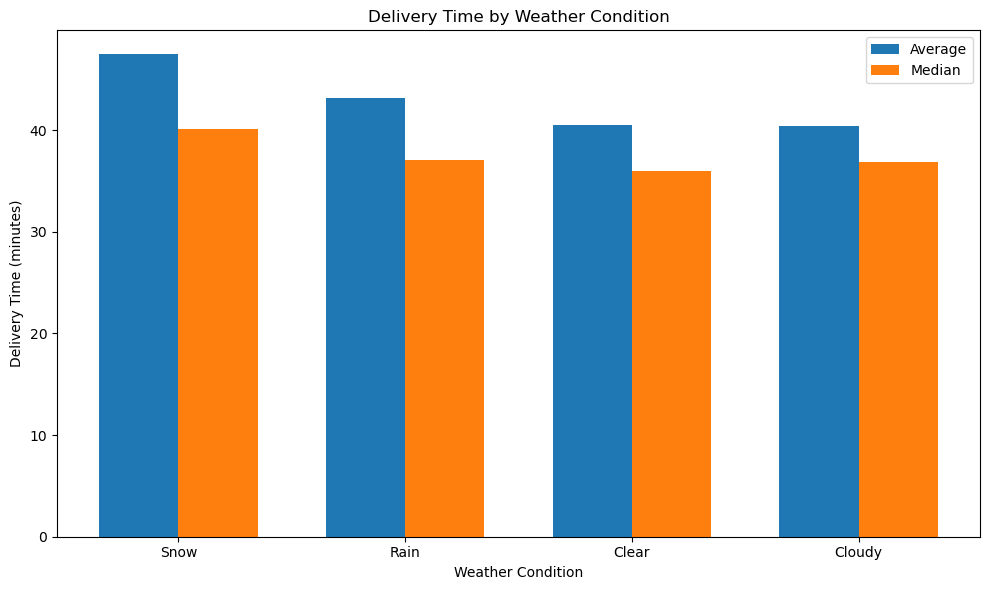

In [5]:
# ============================================================
# BUSINESS QUESTION 3
# Does bad weather slow deliveries down enough to justify
# a weather-based delivery surcharge?
#
# Chart: Average vs median delivery time by weather
# ============================================================


weather_analysis = (
    deliveries
    .groupby("weather_condition")
    .agg(
        total_deliveries=("delivery_id", "count"),
        avg_delivery_minutes=("actual_delivery_minutes", "mean"),
        median_delivery_minutes=("actual_delivery_minutes", "median")
    )
    .reset_index()
    .sort_values("avg_delivery_minutes", ascending=False)
)

print(weather_analysis)

x = np.arange(len(weather_analysis))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    weather_analysis["avg_delivery_minutes"],
    width,
    label="Average"
)

plt.bar(
    x + width / 2,
    weather_analysis["median_delivery_minutes"],
    width,
    label="Median"
)

plt.xticks(
    x,
    weather_analysis["weather_condition"]
)

plt.xlabel("Weather Condition")
plt.ylabel("Delivery Time (minutes)")
plt.title("Delivery Time by Weather Condition")
plt.legend()

plt.tight_layout()
plt.show()

     cuisine_type  total_orders  total_revenue_eur  avg_order_value_eur
0          Bakery           191            2718.83            14.234712
1         Burgers           118            1634.26            13.849661
2         Chinese           546            7342.45            13.447711
3          French           293            4091.69            13.964812
4           Greek           159            2325.17            14.623711
5          Indian            83            1373.36            16.546506
6         Italian           284            4664.80            16.425352
7        Japanese           191            2671.77            13.988325
8   Local Cuisine           353            4529.89            12.832550
9   Mediterranean           299            3442.82            11.514448
10        Mexican           202            2061.42            10.205050
11          Pizza           432            5419.14            12.544306
12        Spanish           425            5179.44            12

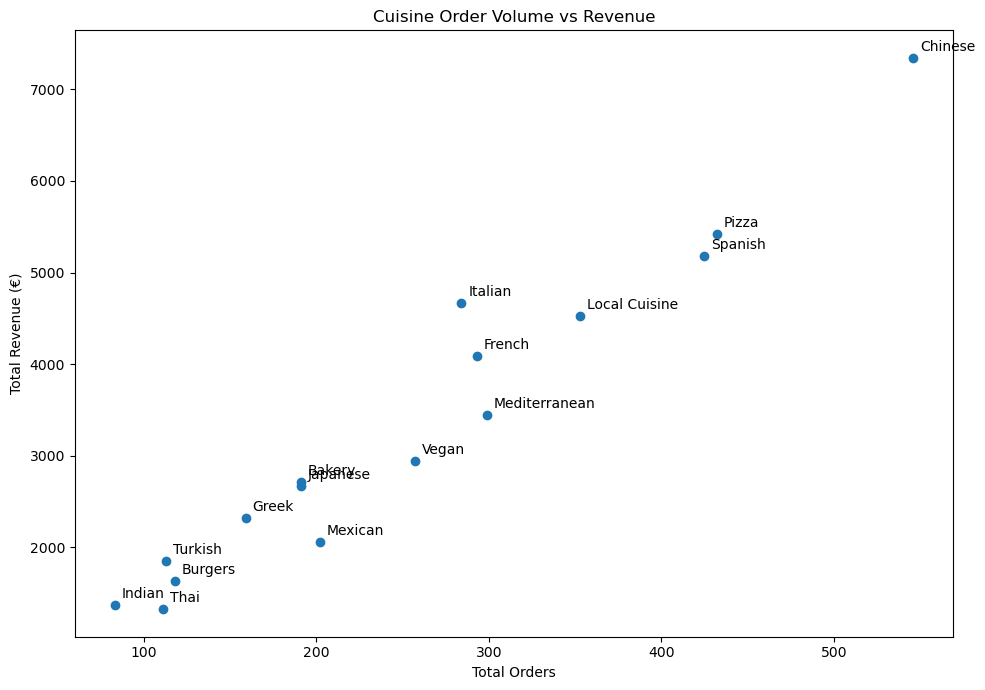

In [6]:
# ============================================================
# BUSINESS QUESTION 4
# Which cuisines bring in the most revenue versus the most
# orders — and is there a mismatch worth investigating?
#
# Chart: Orders vs Revenue scatter plot
# ============================================================


cuisine_analysis = (
    orders[
        [
            "order_id",
            "restaurant_id",
            "total_amount_eur",
            "order_status"
        ]
    ]
    .merge(
        restaurants[
            ["restaurant_id", "cuisine_type"]
        ],
        on="restaurant_id",
        how="left"
    )
)

cuisine_analysis = (
    cuisine_analysis[
        cuisine_analysis["order_status"] == "Delivered"
    ]
    .groupby("cuisine_type")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue_eur=("total_amount_eur", "sum"),
        avg_order_value_eur=("total_amount_eur", "mean")
    )
    .reset_index()
)

print(cuisine_analysis)

plt.figure(figsize=(10, 7))

plt.scatter(
    cuisine_analysis["total_orders"],
    cuisine_analysis["total_revenue_eur"]
)

for _, row in cuisine_analysis.iterrows():
    plt.annotate(
        row["cuisine_type"],
        (
            row["total_orders"],
            row["total_revenue_eur"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Total Orders")
plt.ylabel("Total Revenue (€)")
plt.title("Cuisine Order Volume vs Revenue")

plt.tight_layout()
plt.show()

  customer_segment  total_customers  total_orders  total_revenue_eur  \
0           Budget              474          1350           17324.28   
1          Premium              294           826           10728.90   
2          Regular              614          1881           25523.15   

   avg_order_value_eur  orders_per_customer  revenue_per_customer  
0            12.832800             2.848101             36.549114  
1            12.988983             2.809524             36.492857  
2            13.568926             3.063518             41.568648  


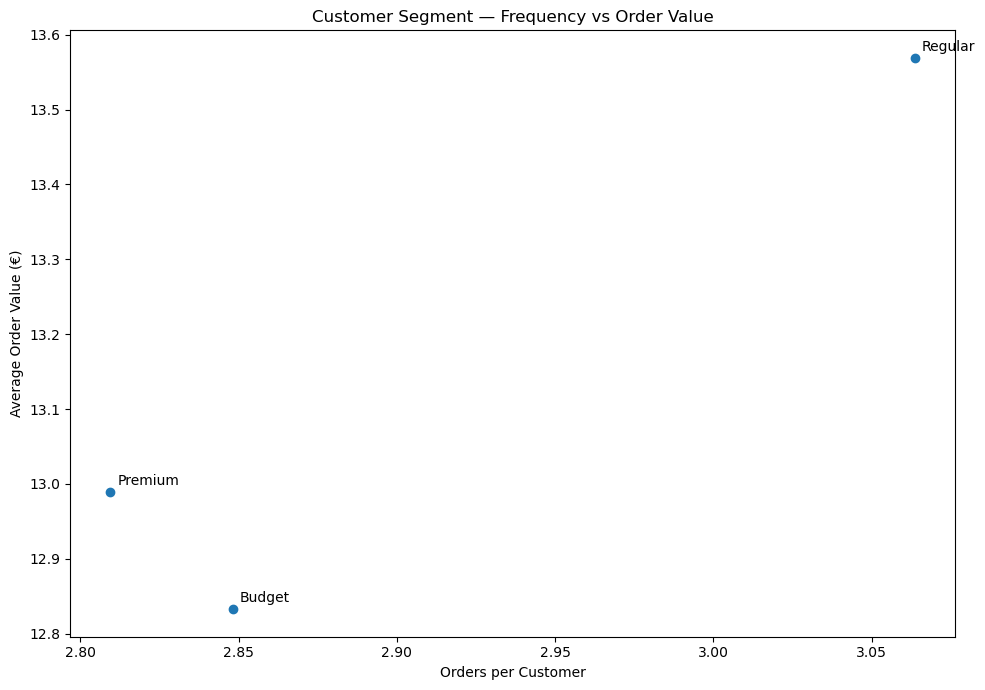

In [7]:
# ============================================================
# BUSINESS QUESTION 5
# Are Premium customers actually more valuable to the business,
# or do they just order more often at a similar order value?
#
# Chart: Orders per customer vs average order value
# ============================================================


customer_analysis = (
    orders[
        [
            "order_id",
            "customer_id",
            "total_amount_eur",
            "order_status"
        ]
    ]
    .merge(
        customers[
            ["customer_id", "customer_segment"]
        ],
        on="customer_id",
        how="left"
    )
)

customer_analysis = (
    customer_analysis[
        customer_analysis["order_status"] == "Delivered"
    ]
    .groupby("customer_segment")
    .agg(
        total_customers=("customer_id", "nunique"),
        total_orders=("order_id", "count"),
        total_revenue_eur=("total_amount_eur", "sum"),
        avg_order_value_eur=("total_amount_eur", "mean")
    )
    .reset_index()
)

customer_analysis["orders_per_customer"] = (
    customer_analysis["total_orders"]
    / customer_analysis["total_customers"]
)

customer_analysis["revenue_per_customer"] = (
    customer_analysis["total_revenue_eur"]
    / customer_analysis["total_customers"]
)

print(customer_analysis)

plt.figure(figsize=(10, 7))

plt.scatter(
    customer_analysis["orders_per_customer"],
    customer_analysis["avg_order_value_eur"]
)

for _, row in customer_analysis.iterrows():
    plt.annotate(
        row["customer_segment"],
        (
            row["orders_per_customer"],
            row["avg_order_value_eur"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Orders per Customer")
plt.ylabel("Average Order Value (€)")
plt.title("Customer Segment — Frequency vs Order Value")

plt.tight_layout()
plt.show()

    restaurant_id  total_orders               restaurant_name  \
0               1            20                  Casa Lefevre   
1              10            37             Fernandez Express   
2             100            71                 Nikolaou Deli   
3             101            49                  Little Pizza   
4             102            13          The Thai Spot (Lyon)   
..            ...           ...                           ...   
115            95            30                   Jensen Deli   
116            96            27  Nikolaou Express (Amsterdam)   
117            97            13                Spanish Corner   
118            98            17        The Pizza Plate (Brno)   
119            99            34                 Indian Garden   

     restaurant_rating  
0                  4.2  
1                  4.4  
2                  3.9  
3                  3.7  
4                  3.7  
..                 ...  
115                4.4  
116                

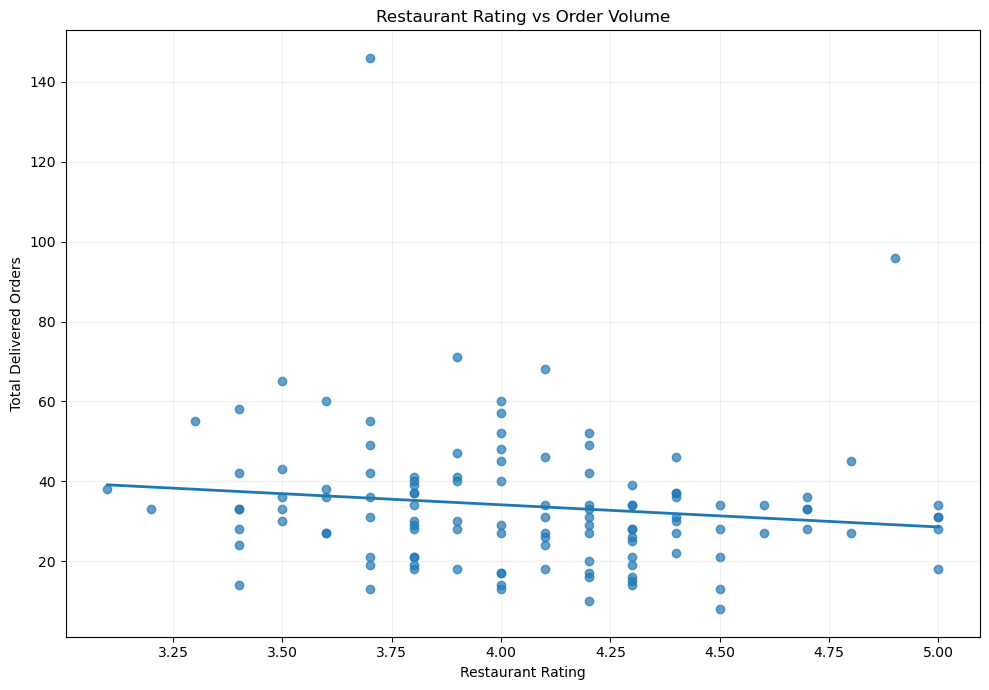

Correlation: -0.13617535737752123


In [8]:
# ============================================================
# BUSINESS QUESTION 6
# Do higher-rated restaurants actually get more business,
# or is rating disconnected from order volume?
#
# Chart: Restaurant Rating vs Order Volume
# ============================================================


restaurant_business = (
    orders[orders["order_status"] == "Delivered"]
    .groupby("restaurant_id")
    .agg(
        total_orders=("order_id", "count")
    )
    .reset_index()
    .merge(
        restaurants[
            ["restaurant_id", "restaurant_name", "restaurant_rating"]
        ],
        on="restaurant_id",
        how="left"
    )
)

restaurant_business = restaurant_business.dropna(
    subset=["restaurant_rating", "total_orders"]
)

print(restaurant_business)

x = restaurant_business["restaurant_rating"]
y = restaurant_business["total_orders"]

plt.figure(figsize=(10, 7))

plt.scatter(
    x,
    y,
    alpha=0.7
)

# Trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.plot(
    x.sort_values(),
    p(x.sort_values()),
    linewidth=2
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Total Delivered Orders")
plt.title("Restaurant Rating vs Order Volume")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    "Correlation:",
    restaurant_business[
        ["restaurant_rating", "total_orders"]
    ].corr().iloc[0, 1]
)

   vehicle_type distance_category  deliveries  avg_delivery_minutes
0       Bicycle    Short Distance         120             35.644167
1       Bicycle   Medium Distance          70             52.441429
2       Bicycle     Long Distance          26             95.434615
3           Car    Short Distance          81             32.081481
4           Car   Medium Distance          30             41.070000
5           Car     Long Distance          22             66.472727
6        E-Bike    Short Distance         147             34.604082
7        E-Bike   Medium Distance          80             45.917500
8        E-Bike     Long Distance          42             76.097619
9    Motorcycle    Short Distance         129             32.321705
10   Motorcycle   Medium Distance          72             38.438889
11   Motorcycle     Long Distance          24             56.358333
12      Scooter    Short Distance          92             30.938043
13      Scooter   Medium Distance          50   

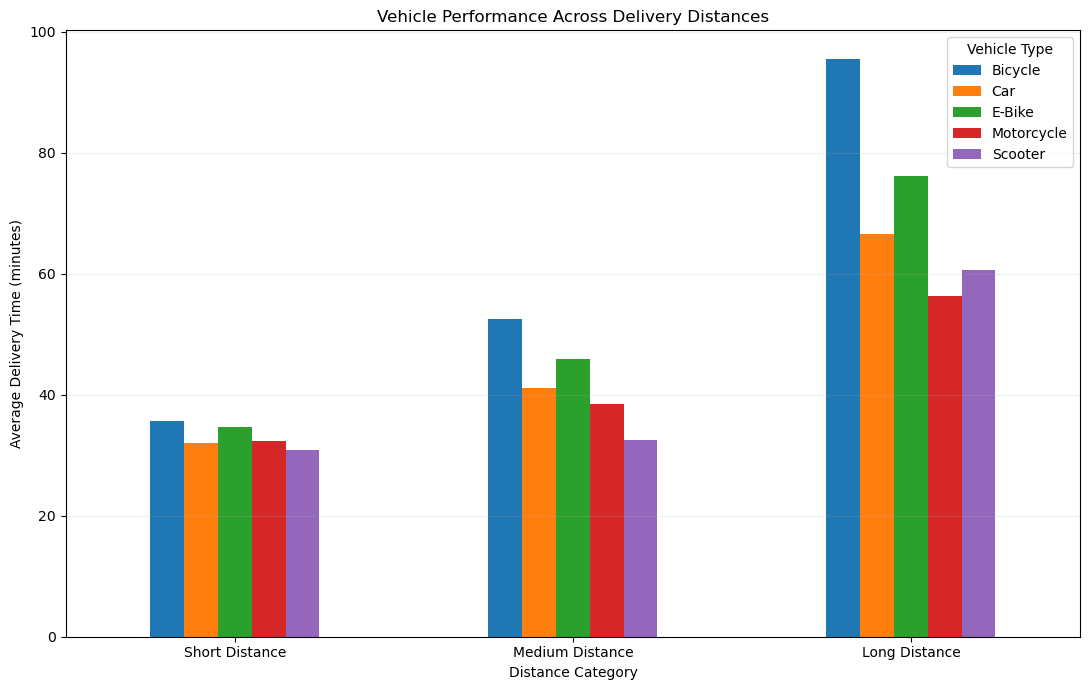

In [9]:
# ============================================================
# BUSINESS QUESTION 7
# Which vehicle types work best for short-distance deliveries
# versus long-distance ones?
#
# Chart: Vehicle Performance by Distance
# ============================================================


vehicle_analysis = deliveries.merge(
    orders[["order_id", "restaurant_id"]],
    on="order_id",
    how="left"
).merge(
    drivers[
        ["driver_id", "vehicle_type"]
    ],
    on="driver_id",
    how="left"
)

vehicle_analysis["distance_category"] = pd.cut(
    vehicle_analysis["distance_km"],
    bins=[-np.inf, 3, 7, np.inf],
    labels=[
        "Short Distance",
        "Medium Distance",
        "Long Distance"
    ]
)

vehicle_summary = (
    vehicle_analysis
    .groupby(
        ["vehicle_type", "distance_category"],
        observed=True
    )
    .agg(
        deliveries=("delivery_id", "count"),
        avg_delivery_minutes=("actual_delivery_minutes", "mean")
    )
    .reset_index()
)

print(vehicle_summary)

pivot = vehicle_summary.pivot(
    index="distance_category",
    columns="vehicle_type",
    values="avg_delivery_minutes"
)

pivot.plot(
    kind="bar",
    figsize=(11, 7)
)

plt.xlabel("Distance Category")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Vehicle Performance Across Delivery Distances")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.legend(title="Vehicle Type")

plt.tight_layout()
plt.show()

  discount_group  total_orders  avg_items  avg_order_value  avg_discount
0     Discounted           812   1.523399        12.034175      1.346773
1    No Discount          3688   1.526844        13.409257      0.000000


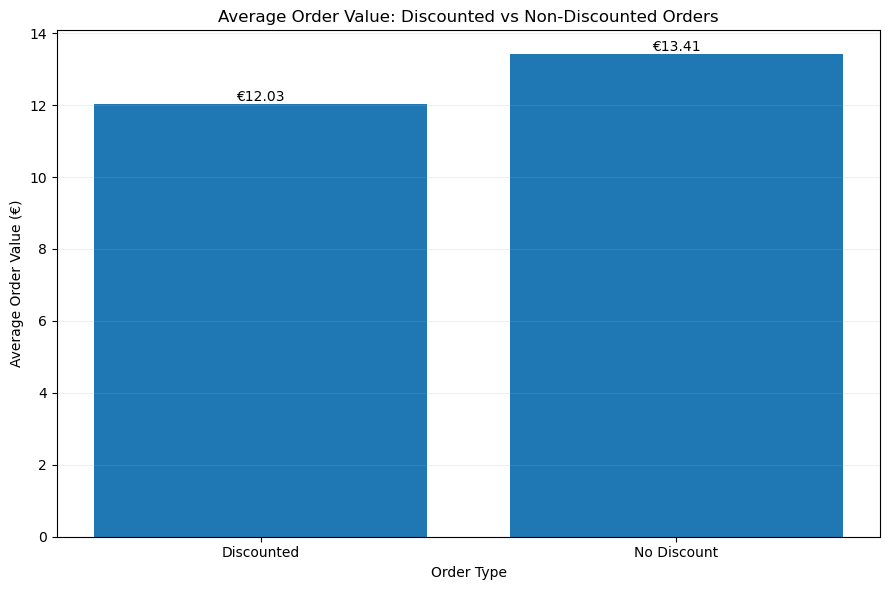

In [10]:
# ============================================================
# BUSINESS QUESTION 8
# Do discounted orders meaningfully increase how much customers
# buy, or are we mostly discounting orders that would have
# happened anyway?
#
# Chart: Discount vs Order Value
# ============================================================


orders_discount = orders.copy()

orders_discount["discount_group"] = np.where(
    orders_discount["discount_eur"] > 0,
    "Discounted",
    "No Discount"
)

discount_analysis = (
    orders_discount
    .groupby("discount_group")
    .agg(
        total_orders=("order_id", "count"),
        avg_items=("number_of_items", "mean"),
        avg_order_value=("total_amount_eur", "mean"),
        avg_discount=("discount_eur", "mean")
    )
    .reset_index()
)

print(discount_analysis)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    discount_analysis["discount_group"],
    discount_analysis["avg_order_value"]
)

plt.ylabel("Average Order Value (€)")
plt.xlabel("Order Type")
plt.title("Average Order Value: Discounted vs Non-Discounted Orders")
plt.grid(axis="y", alpha=0.2)

for bar, value in zip(
    bars,
    discount_analysis["avg_order_value"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"€{value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

  discount_group  total_orders  avg_items  avg_order_value  avg_discount
0     Discounted           812   1.523399        12.034175      1.346773
1    No Discount          3688   1.526844        13.409257      0.000000


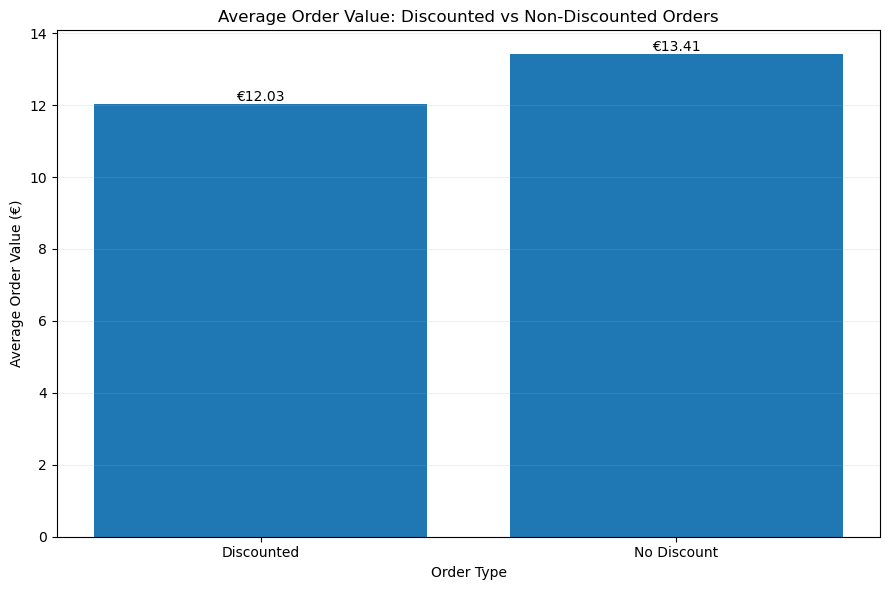

In [11]:
# ============================================================
# BUSINESS QUESTION 8
# Do discounted orders meaningfully increase how much customers
# buy, or are we mostly discounting orders that would have
# happened anyway?
#
# Chart: Discount vs Order Value
# ============================================================



orders_discount = orders.copy()

orders_discount["discount_group"] = np.where(
    orders_discount["discount_eur"] > 0,
    "Discounted",
    "No Discount"
)

discount_analysis = (
    orders_discount
    .groupby("discount_group")
    .agg(
        total_orders=("order_id", "count"),
        avg_items=("number_of_items", "mean"),
        avg_order_value=("total_amount_eur", "mean"),
        avg_discount=("discount_eur", "mean")
    )
    .reset_index()
)

print(discount_analysis)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    discount_analysis["discount_group"],
    discount_analysis["avg_order_value"]
)

plt.ylabel("Average Order Value (€)")
plt.xlabel("Order Type")
plt.title("Average Order Value: Discounted vs Non-Discounted Orders")
plt.grid(axis="y", alpha=0.2)

for bar, value in zip(
    bars,
    discount_analysis["avg_order_value"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"€{value:,.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

    driver_id  avg_delivery_time  total_deliveries  years_experience  \
2         100          54.728571                 7               0.4   
7         105          35.660000                 5               0.7   
10        108          42.420000                 5               7.6   
11        109          45.240000                 5               2.0   
13        110          31.828571                 7               0.1   
..        ...                ...               ...               ...   
280        57          38.500000                 6               1.8   
288        65          38.020000                 5               0.8   
300        77          38.620000                 5               1.1   
316        95          31.040000                 5               4.2   
318        97          53.185714                 7               0.7   

     driver_rating  
2             3.38  
7             3.55  
10            4.44  
11            3.75  
13            3.50  
..       

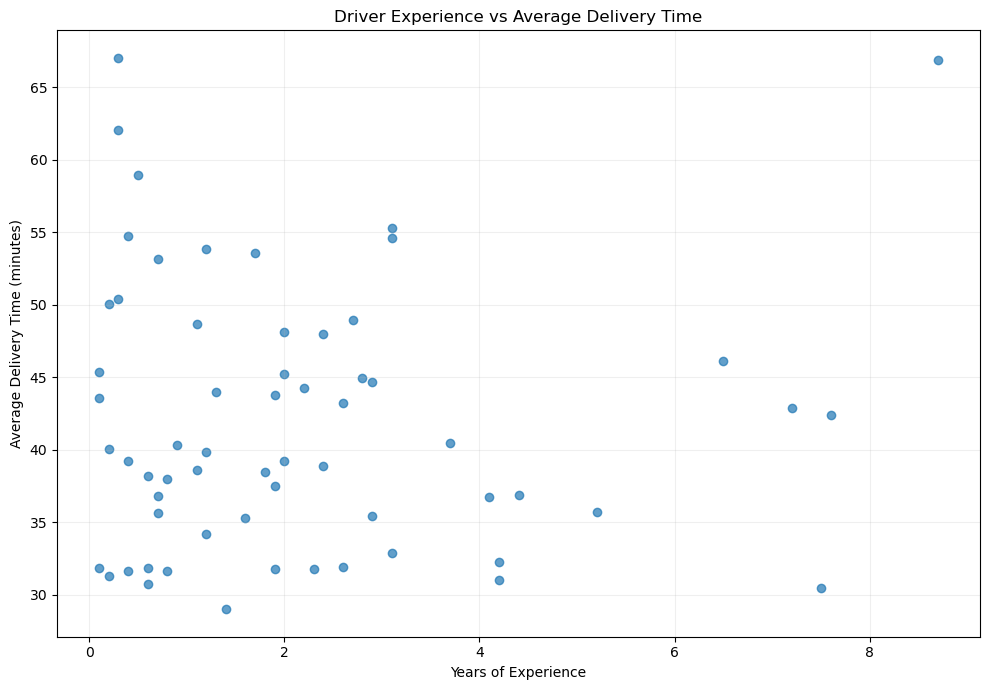

Experience vs delivery time correlation: 0.011280522604568136
Experience vs driver rating correlation: 0.5712329609577382


In [12]:
# ============================================================
# BUSINESS QUESTION 10
# Does driver experience actually translate into faster or
# better-rated deliveries?
#
# Chart: Driver Experience vs Delivery Time
# ============================================================


driver_performance = (
    deliveries
    .groupby("driver_id")
    .agg(
        avg_delivery_time=("actual_delivery_minutes", "mean"),
        total_deliveries=("delivery_id", "count")
    )
    .reset_index()
    .merge(
        drivers[
            [
                "driver_id",
                "years_experience",
                "driver_rating"
            ]
        ],
        on="driver_id",
        how="left"
    )
)

driver_performance = driver_performance[
    driver_performance["total_deliveries"] >= 5
].dropna()

print(driver_performance)

plt.figure(figsize=(10, 7))

plt.scatter(
    driver_performance["years_experience"],
    driver_performance["avg_delivery_time"],
    alpha=0.7
)

plt.xlabel("Years of Experience")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Driver Experience vs Average Delivery Time")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(
    "Experience vs delivery time correlation:",
    driver_performance[
        ["years_experience", "avg_delivery_time"]
    ].corr().iloc[0, 1]
)

print(
    "Experience vs driver rating correlation:",
    driver_performance[
        ["years_experience", "driver_rating"]
    ].corr().iloc[0, 1]
)

    restaurant_id                restaurant_name      country          city  \
19            116                  Janssens Deli       France         Paris   
98             80                   Little Greek       Greece  Thessaloniki   
112            93          Bakery & Co. (Lisbon)     Portugal        Lisbon   
5             103     Pizza Street Food (Athens)       Greece        Athens   
117            98         The Pizza Plate (Brno)      Czechia          Brno   
99             81                  Bakery Garden       Sweden     Stockholm   
76             60                The Pizza Plate        Italy         Milan   
111            92  Pizza Street Food (Amsterdam)  Netherlands     Amsterdam   
55             41         Chinese Corner (Paris)       France         Paris   
36             24                  Burgers House        Spain     Barcelona   
65             50                     Casa Meyer     Portugal        Lisbon   

     total_deliveries  average_preparation_time  av

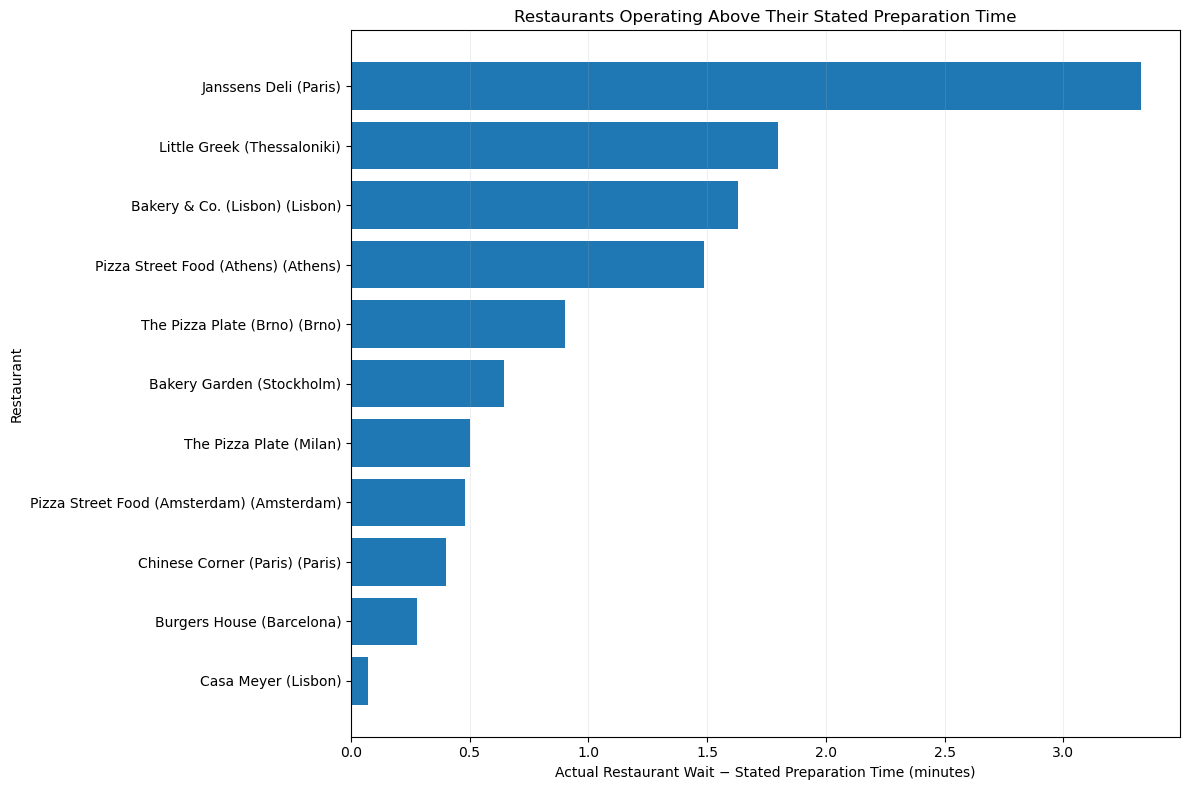

In [13]:
# ============================================================
# BUSINESS QUESTION 11
# Which restaurants consistently run slower than their own
# stated prep time would suggest?
#
# Chart: Stated Preparation Time vs Actual Restaurant Wait
# ============================================================


# ------------------------------------------------------------
# 1. Combine restaurant and delivery information
# ------------------------------------------------------------

restaurant_prep = (
    deliveries[
        [
            "order_id",
            "restaurant_wait_minutes"
        ]
    ]
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "restaurant_name",
                "country",
                "city",
                "average_preparation_time"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
)

# ------------------------------------------------------------
# 2. Calculate actual average restaurant wait
# ------------------------------------------------------------

restaurant_prep_summary = (
    restaurant_prep
    .groupby(
        [
            "restaurant_id",
            "restaurant_name",
            "country",
            "city",
            "average_preparation_time"
        ]
    )
    .agg(
        total_deliveries=("order_id", "count"),
        avg_actual_wait=("restaurant_wait_minutes", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Calculate difference from stated preparation time
# ------------------------------------------------------------

restaurant_prep_summary["prep_time_difference"] = (
    restaurant_prep_summary["avg_actual_wait"]
    - restaurant_prep_summary["average_preparation_time"]
)

restaurant_prep_summary["slower_than_stated"] = (
    restaurant_prep_summary["prep_time_difference"] > 0
)

# ------------------------------------------------------------
# 4. Show restaurants consistently slower than stated time
# ------------------------------------------------------------

slow_restaurants = (
    restaurant_prep_summary[
        restaurant_prep_summary["slower_than_stated"]
    ]
    .sort_values(
        "prep_time_difference",
        ascending=False
    )
)

print(
    slow_restaurants[
        [
            "restaurant_id",
            "restaurant_name",
            "country",
            "city",
            "total_deliveries",
            "average_preparation_time",
            "avg_actual_wait",
            "prep_time_difference"
        ]
    ].head(20)
)

# ------------------------------------------------------------
# 5. Chart — Top 15 restaurants with largest gap
# ------------------------------------------------------------

chart_data = slow_restaurants.head(15).copy()

chart_data["restaurant_label"] = (
    chart_data["restaurant_name"]
    + " (" 
    + chart_data["city"]
    + ")"
)

plt.figure(figsize=(12, 8))

plt.barh(
    chart_data["restaurant_label"][::-1],
    chart_data["prep_time_difference"][::-1]
)

plt.xlabel(
    "Actual Restaurant Wait − Stated Preparation Time (minutes)"
)

plt.ylabel("Restaurant")

plt.title(
    "Restaurants Operating Above Their Stated Preparation Time"
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

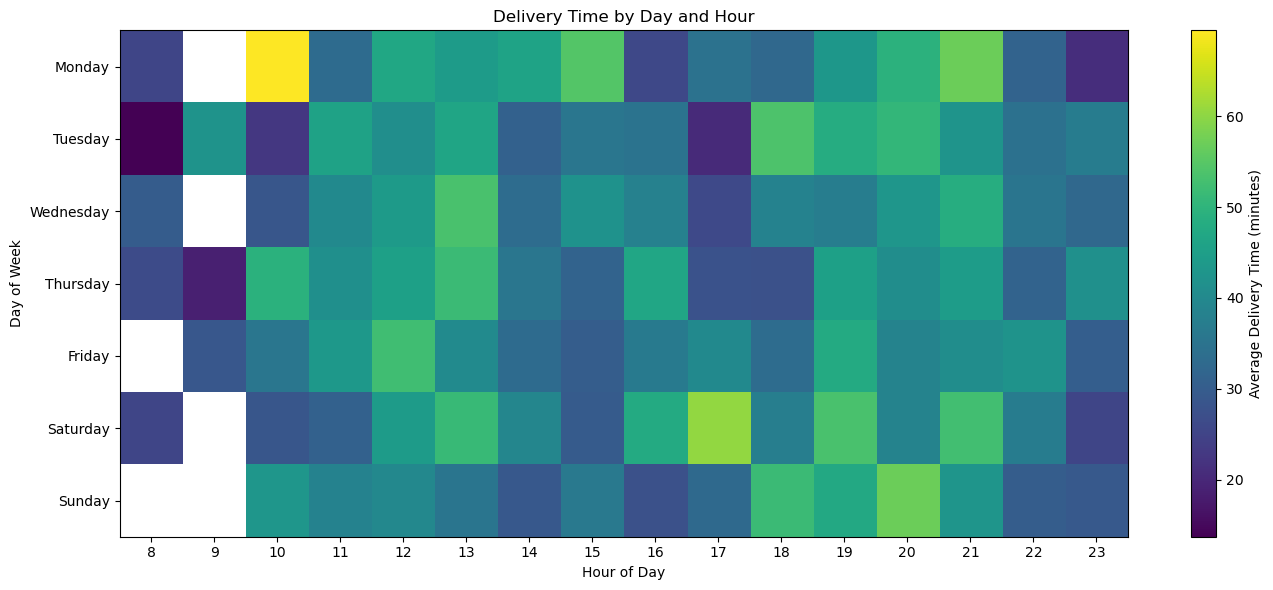

In [14]:
# ============================================================
# BUSINESS QUESTION 12
# How much of the swing in delivery time comes down to
# time-of-day and day-of-week congestion, versus other factors?
#
# Chart: Day-of-Week × Hour Delivery Time Heatmap
# ============================================================

import matplotlib.pyplot as plt

orders_time = orders[
    [
        "order_id",
        "order_datetime"
    ]
].copy()

orders_time["day_of_week"] = (
    orders_time["order_datetime"]
    .dt.day_name()
)

orders_time["hour"] = (
    orders_time["order_datetime"]
    .dt.hour
)

time_delivery = deliveries[
    [
        "order_id",
        "actual_delivery_minutes"
    ]
].merge(
    orders_time,
    on="order_id",
    how="left"
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = (
    time_delivery
    .groupby(
        ["day_of_week", "hour"]
    )["actual_delivery_minutes"]
    .mean()
    .unstack()
    .reindex(day_order)
)

plt.figure(figsize=(14, 6))

plt.imshow(
    heatmap_data,
    aspect="auto"
)

plt.colorbar(
    label="Average Delivery Time (minutes)"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("Delivery Time by Day and Hour")

plt.tight_layout()
plt.show()

                         actual_delivery_minutes    rating
actual_delivery_minutes                 1.000000 -0.434822
rating                                 -0.434822  1.000000


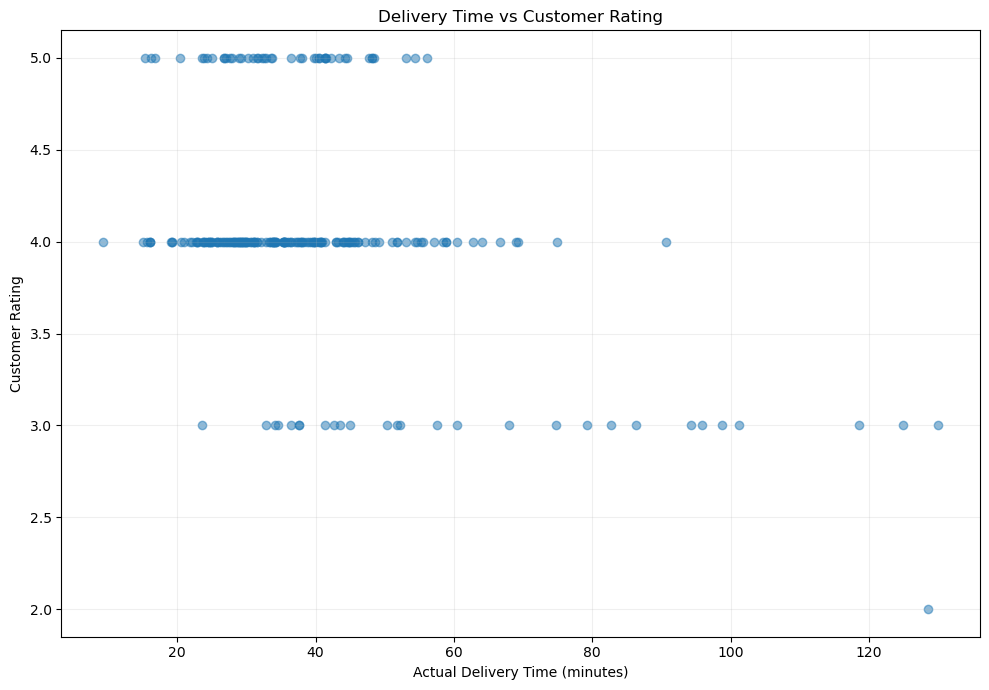

In [15]:
# ============================================================
# BUSINESS QUESTION 13
# Do customers who get a slow delivery leave worse reviews,
# and does that pattern hold across every country?
#
# Chart: Delivery Time vs Customer Rating
# ============================================================

review_delivery = (
    deliveries[
        [
            "order_id",
            "actual_delivery_minutes"
        ]
    ]
    .merge(
        reviews[
            [
                "order_id",
                "rating"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "country"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
)

print(
    review_delivery[
        [
            "actual_delivery_minutes",
            "rating"
        ]
    ].corr()
)

plt.figure(figsize=(10, 7))

plt.scatter(
    review_delivery["actual_delivery_minutes"],
    review_delivery["rating"],
    alpha=0.5
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.title("Delivery Time vs Customer Rating")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

        country  total_customers  total_orders  total_revenue_eur  \
0       Austria               53           150            2376.00   
1       Belgium               79           209            2720.96   
2       Czechia               59           166            1539.95   
3       Denmark               44           116            1877.26   
4       Finland               44           131            1916.83   
5        France              182           465            6668.80   
6       Germany              256           699            9722.99   
7        Greece               62           160            1573.94   
8         Italy              183           490            6511.85   
9   Netherlands              101           275            4945.58   
10       Norway               48           114            1610.69   
11       Poland              111           306            2817.17   
12     Portugal               57           178            1777.54   
13        Spain              137  

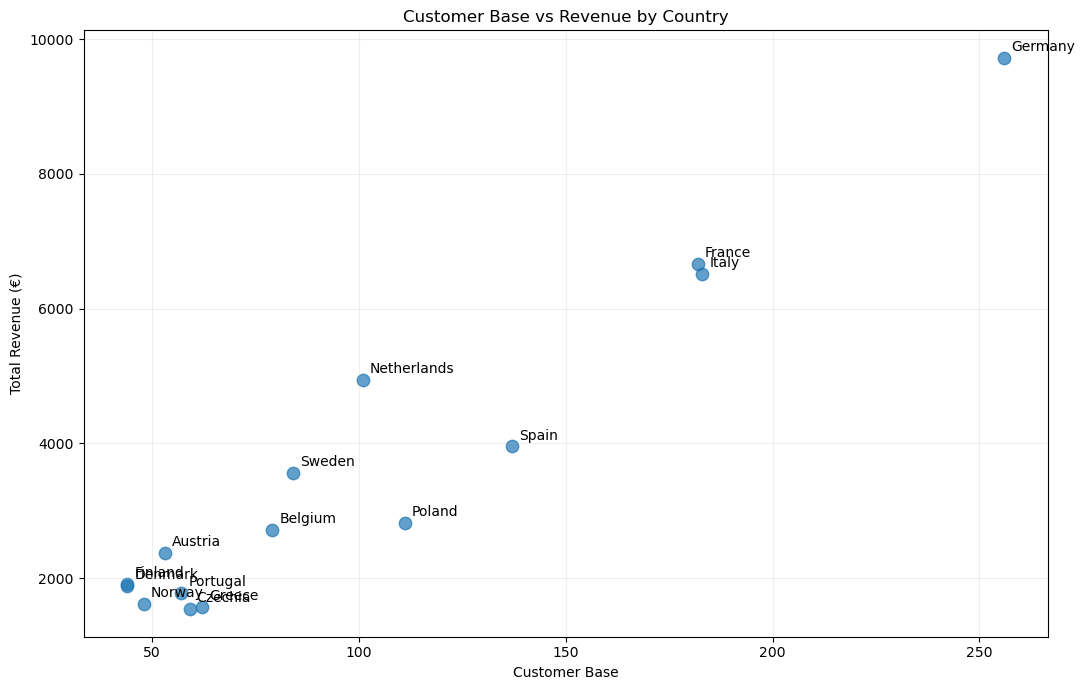

In [16]:
# ============================================================
# BUSINESS QUESTION 14
# Which countries or cities look like the best growth
# opportunity, given how many customers we already have there?
#
# Chart: Customer Base vs Revenue by Country
# ============================================================

country_customers = (
    customers
    .groupby("country")
    .agg(
        total_customers=("customer_id", "nunique")
    )
    .reset_index()
)

country_revenue = (
    orders[
        orders["order_status"] == "Delivered"
    ]
    .merge(
        restaurants[
            ["restaurant_id", "country"]
        ],
        on="restaurant_id",
        how="left"
    )
    .groupby("country")
    .agg(
        total_orders=("order_id", "count"),
        total_revenue_eur=("total_amount_eur", "sum")
    )
    .reset_index()
)

growth_analysis = country_customers.merge(
    country_revenue,
    on="country",
    how="left"
).fillna(0)

growth_analysis["revenue_per_customer"] = (
    growth_analysis["total_revenue_eur"]
    / growth_analysis["total_customers"]
)

print(growth_analysis)

plt.figure(figsize=(11, 7))

plt.scatter(
    growth_analysis["total_customers"],
    growth_analysis["total_revenue_eur"],
    s=80,
    alpha=0.7
)

for _, row in growth_analysis.iterrows():
    plt.annotate(
        row["country"],
        (
            row["total_customers"],
            row["total_revenue_eur"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Customer Base")
plt.ylabel("Total Revenue (€)")
plt.title("Customer Base vs Revenue by Country")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

   order_month  total_revenue_eur
0      2025-09            3800.08
1      2025-10            3684.25
2      2025-11            3793.39
3      2025-12            3919.95
4      2026-01            4253.32
5      2026-02            3585.70
6      2026-03            4561.39
7      2026-04            4304.38
8      2026-05            5090.45
9      2026-06            4847.75
10     2026-07            5797.49
11     2026-08            5910.86
12     2026-09              27.32


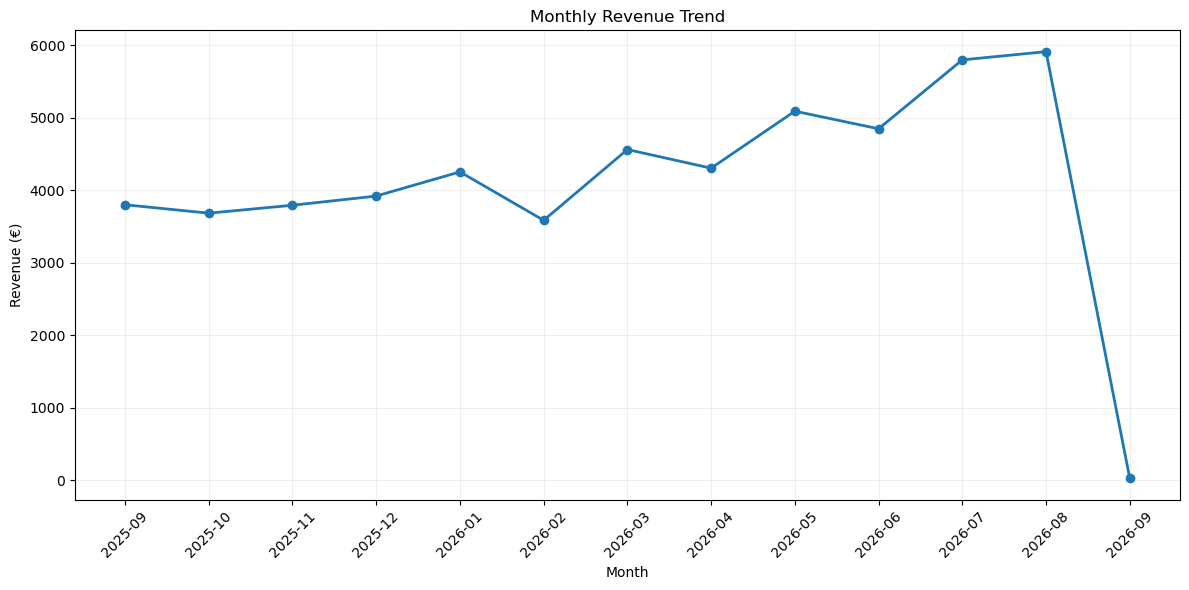

   order_month  avg_delivery_minutes
0      2025-09             39.778689
1      2025-10             39.603409
2      2025-11             41.714493
3      2025-12             41.020548
4      2026-01             42.164634
5      2026-02             44.682609
6      2026-03             41.282895
7      2026-04             39.515789
8      2026-05             40.837778
9      2026-06             41.950562
10     2026-07             40.766327
11     2026-08             42.552756
12     2026-09             38.750000


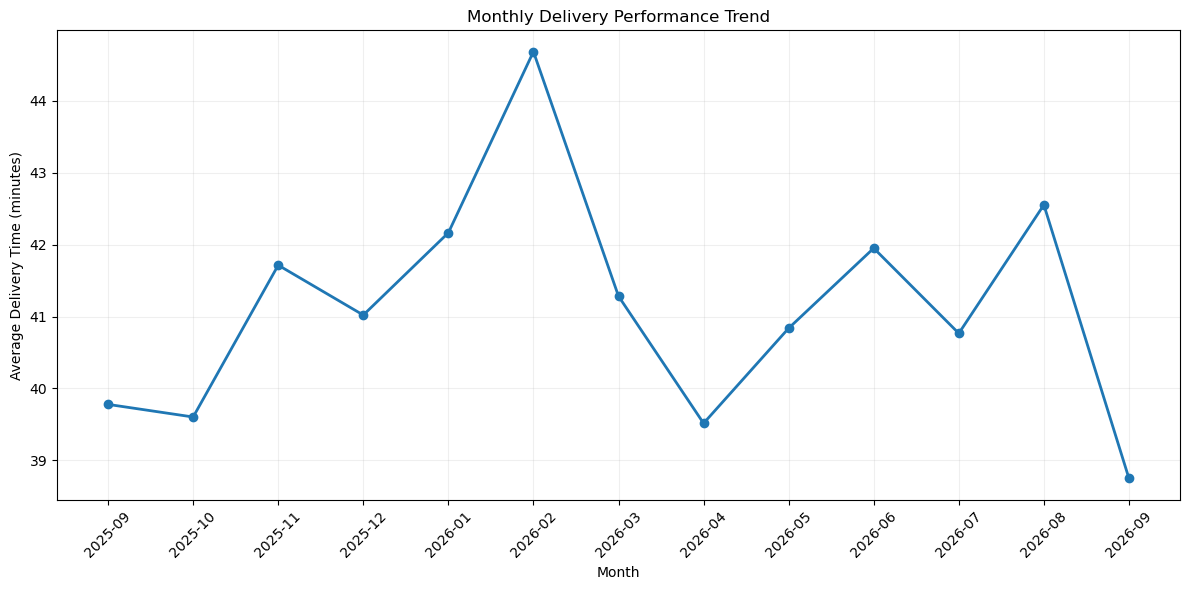

In [17]:
# ============================================================
# BUSINESS QUESTION 15
# Is there a seasonal pattern to revenue or delivery
# performance that the business should plan around?
#
# Chart: Monthly Revenue Trend
# ============================================================


orders["order_month"] = (
    orders["order_datetime"]
    .dt.to_period("M")
)

monthly_revenue = (
    orders[
        orders["order_status"] == "Delivered"
    ]
    .groupby("order_month")
    .agg(
        total_revenue_eur=("total_amount_eur", "sum")
    )
    .reset_index()
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_month"]
    .astype(str)
)

print(monthly_revenue)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["total_revenue_eur"],
    marker="o",
    linewidth=2
)

plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ============================================================
# MONTHLY DELIVERY PERFORMANCE
# ============================================================

delivery_monthly = (
    deliveries[
        [
            "order_id",
            "actual_delivery_minutes"
        ]
    ]
    .merge(
        orders[
            [
                "order_id",
                "order_datetime"
            ]
        ],
        on="order_id",
        how="left"
    )
)

delivery_monthly["order_month"] = (
    delivery_monthly["order_datetime"]
    .dt.to_period("M")
    .astype(str)
)

monthly_delivery = (
    delivery_monthly
    .groupby("order_month")
    .agg(
        avg_delivery_minutes=(
            "actual_delivery_minutes",
            "mean"
        )
    )
    .reset_index()
)

print(monthly_delivery)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_delivery["order_month"],
    monthly_delivery["avg_delivery_minutes"],
    marker="o",
    linewidth=2
)

plt.xlabel("Month")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Monthly Delivery Performance Trend")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

ORDER SIZE ANALYSIS
  order_size  total_orders  avg_restaurant_wait  avg_delivery_time
0  1–2 Items           882                18.76              41.35
1  3–4 Items           111                21.66              40.30
2  5–6 Items             6                21.47              58.72
3   7+ Items             1                29.30              58.10

RESTAURANT SIZE × ORDER SIZE
  restaurant_size order_size  total_orders  avg_restaurant_wait  \
0           Large  1–2 Items           371                20.57   
1           Large  3–4 Items            53                22.58   
2           Large  5–6 Items             2                22.90   
3           Large   7+ Items             1                29.30   
4          Medium  1–2 Items           300                17.25   
5          Medium  3–4 Items            36                21.01   
6          Medium  5–6 Items             1                28.70   
7           Small  1–2 Items           211                17.74   
8           

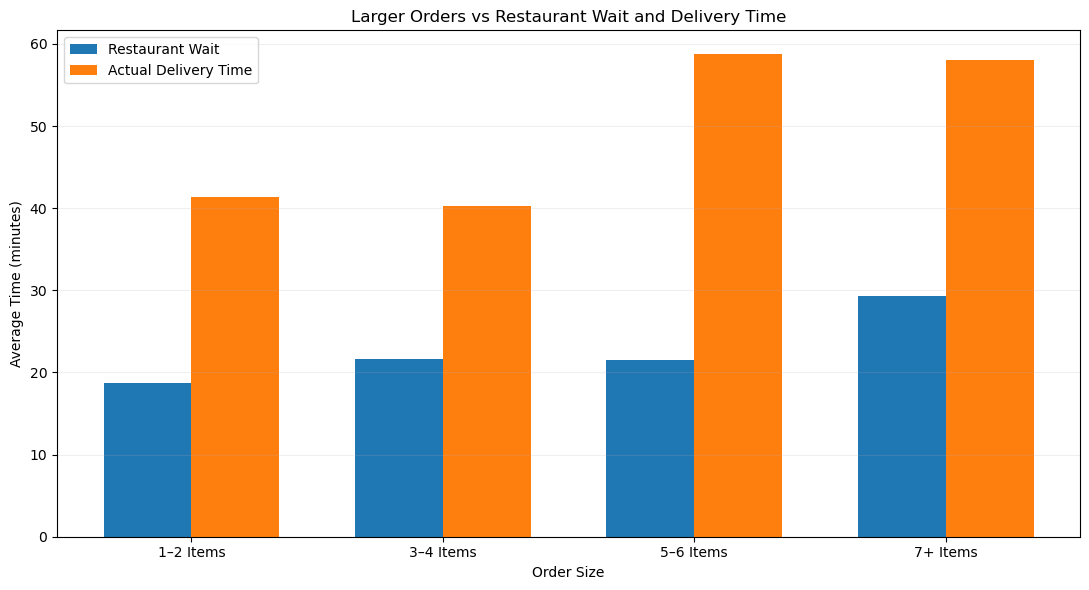

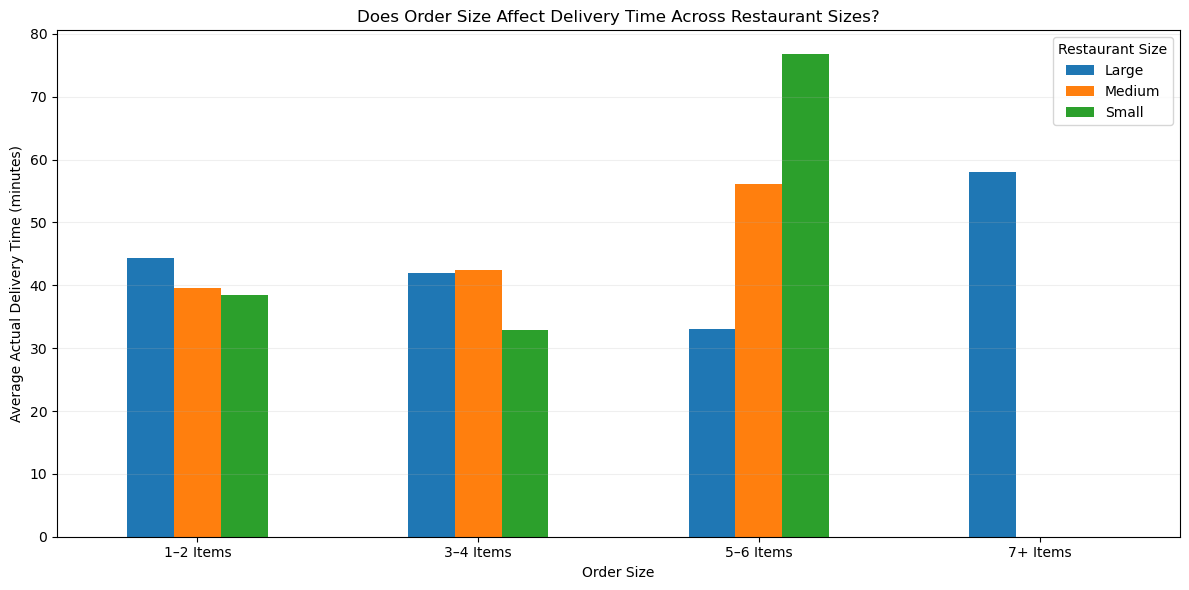

In [18]:
# ============================================================
# BUSINESS QUESTION 16
# Do bigger orders take proportionally longer to prepare and
# deliver, and does that hold across restaurants of every size?
#
# Charts:
# 1. Order Size vs Preparation / Delivery Time
# 2. Restaurant Size vs Order Size and Delivery Time
# ============================================================


# ------------------------------------------------------------
# Prepare order-level dataset
# ------------------------------------------------------------

q16 = (
    orders[
        [
            "order_id",
            "restaurant_id",
            "number_of_items"
        ]
    ]
    .merge(
        deliveries[
            [
                "order_id",
                "restaurant_wait_minutes",
                "actual_delivery_minutes"
            ]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "restaurant_size"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
)

# Numeric conversion
q16["number_of_items"] = pd.to_numeric(
    q16["number_of_items"],
    errors="coerce"
)

q16["restaurant_wait_minutes"] = pd.to_numeric(
    q16["restaurant_wait_minutes"],
    errors="coerce"
)

q16["actual_delivery_minutes"] = pd.to_numeric(
    q16["actual_delivery_minutes"],
    errors="coerce"
)

q16 = q16.dropna(
    subset=[
        "number_of_items",
        "restaurant_wait_minutes",
        "actual_delivery_minutes"
    ]
)

# ------------------------------------------------------------
# Create order-size groups
# ------------------------------------------------------------

q16["order_size"] = pd.cut(
    q16["number_of_items"],
    bins=[0, 2, 4, 6, np.inf],
    labels=["1–2 Items", "3–4 Items", "5–6 Items", "7+ Items"]
)

# ------------------------------------------------------------
# Overall order-size analysis
# ------------------------------------------------------------

order_size_summary = (
    q16
    .groupby("order_size", observed=True)
    .agg(
        total_orders=("order_id", "count"),
        avg_restaurant_wait=("restaurant_wait_minutes", "mean"),
        avg_delivery_time=("actual_delivery_minutes", "mean")
    )
    .reset_index()
)

print("ORDER SIZE ANALYSIS")
print(order_size_summary.round(2))


# ------------------------------------------------------------
# Restaurant-size analysis
# ------------------------------------------------------------

restaurant_size_summary = (
    q16
    .groupby(
        ["restaurant_size", "order_size"],
        observed=True
    )
    .agg(
        total_orders=("order_id", "count"),
        avg_restaurant_wait=("restaurant_wait_minutes", "mean"),
        avg_delivery_time=("actual_delivery_minutes", "mean")
    )
    .reset_index()
)

print("\nRESTAURANT SIZE × ORDER SIZE")
print(restaurant_size_summary.round(2))


# ============================================================
# CHART 1 — Order Size vs Preparation / Delivery Time
# ============================================================

chart1 = order_size_summary.copy()

x = np.arange(len(chart1))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width/2,
    chart1["avg_restaurant_wait"],
    width,
    label="Restaurant Wait"
)

plt.bar(
    x + width/2,
    chart1["avg_delivery_time"],
    width,
    label="Actual Delivery Time"
)

plt.xticks(
    x,
    chart1["order_size"]
)

plt.xlabel("Order Size")
plt.ylabel("Average Time (minutes)")
plt.title(
    "Larger Orders vs Restaurant Wait and Delivery Time"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — Restaurant Size × Order Size
# ============================================================

pivot_delivery = restaurant_size_summary.pivot(
    index="order_size",
    columns="restaurant_size",
    values="avg_delivery_time"
)

ax = pivot_delivery.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Order Size")
plt.ylabel("Average Actual Delivery Time (minutes)")
plt.title(
    "Does Order Size Affect Delivery Time Across Restaurant Sizes?"
)

plt.xticks(rotation=0)
plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend(
    title="Restaurant Size"
)

plt.tight_layout()
plt.show()

OVERALL ESTIMATION RELIABILITY
                   Metric  Value
0  Average Estimated Time  38.92
1     Average Actual Time  41.35
2           Average Error   2.44
3  Average Absolute Error   4.63
4         Average Error %   6.95
5      Within ±10 Minutes  93.00

COUNTRY-LEVEL ESTIMATION RELIABILITY
        country  total_deliveries  avg_estimated_time  avg_actual_time  \
0       Austria                33               46.31            52.75   
7        Greece                38               41.39            45.36   
8         Italy               123               38.58            41.91   
2       Czechia                34               36.14            39.18   
13        Spain                88               35.09            37.85   
12     Portugal                47               34.31            36.93   
5        France               102               35.20            37.80   
9   Netherlands                68               42.03            44.62   
11       Poland                79 

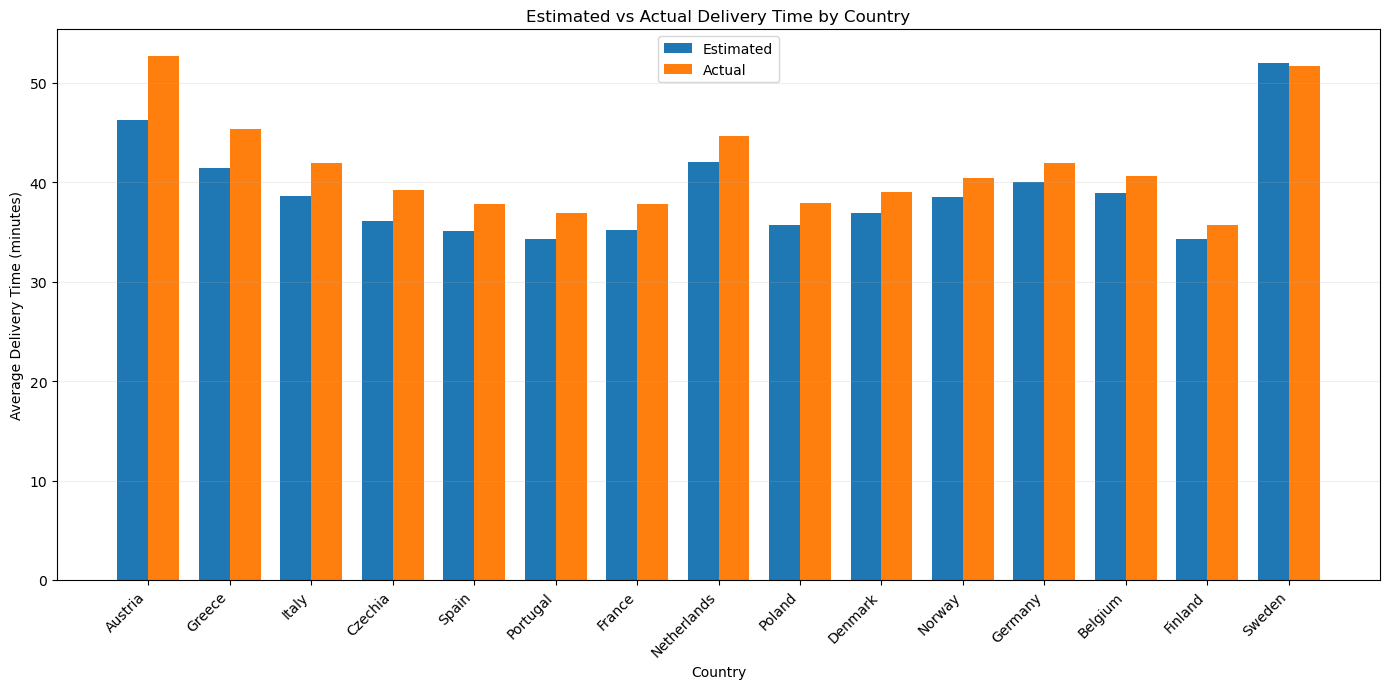

In [19]:
# ============================================================
# BUSINESS QUESTION 17
# How reliable are our delivery-time estimates today, and in
# which countries is the gap between estimated and actual time worst?
#
# Chart:
# Estimated vs Actual Delivery Time by Country
# ============================================================


# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

q17 = (
    deliveries[
        [
            "order_id",
            "estimated_delivery_minutes",
            "actual_delivery_minutes"
        ]
    ]
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "country"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
)

# Numeric conversion
q17["estimated_delivery_minutes"] = pd.to_numeric(
    q17["estimated_delivery_minutes"],
    errors="coerce"
)

q17["actual_delivery_minutes"] = pd.to_numeric(
    q17["actual_delivery_minutes"],
    errors="coerce"
)

q17 = q17.dropna(
    subset=[
        "estimated_delivery_minutes",
        "actual_delivery_minutes",
        "country"
    ]
)

# ------------------------------------------------------------
# Calculate estimation error
# ------------------------------------------------------------

q17["error_minutes"] = (
    q17["actual_delivery_minutes"]
    - q17["estimated_delivery_minutes"]
)

q17["absolute_error_minutes"] = (
    q17["error_minutes"].abs()
)

q17["error_pct"] = (
    q17["error_minutes"]
    / q17["estimated_delivery_minutes"]
) * 100

# ------------------------------------------------------------
# Overall reliability
# ------------------------------------------------------------

overall_reliability = pd.DataFrame({
    "Metric": [
        "Average Estimated Time",
        "Average Actual Time",
        "Average Error",
        "Average Absolute Error",
        "Average Error %",
        "Within ±10 Minutes"
    ],
    "Value": [
        q17["estimated_delivery_minutes"].mean(),
        q17["actual_delivery_minutes"].mean(),
        q17["error_minutes"].mean(),
        q17["absolute_error_minutes"].mean(),
        q17["error_pct"].mean(),
        (
            q17["absolute_error_minutes"] <= 10
        ).mean() * 100
    ]
})

print("OVERALL ESTIMATION RELIABILITY")
print(overall_reliability.round(2))


# ------------------------------------------------------------
# Country-level reliability
# ------------------------------------------------------------

country_reliability = (
    q17
    .groupby("country")
    .agg(
        total_deliveries=("order_id", "count"),
        avg_estimated_time=(
            "estimated_delivery_minutes",
            "mean"
        ),
        avg_actual_time=(
            "actual_delivery_minutes",
            "mean"
        ),
        avg_error_minutes=("error_minutes", "mean"),
        avg_absolute_error=(
            "absolute_error_minutes",
            "mean"
        ),
        avg_error_pct=("error_pct", "mean")
    )
    .reset_index()
)

country_reliability["gap_minutes"] = (
    country_reliability["avg_actual_time"]
    - country_reliability["avg_estimated_time"]
)

country_reliability = country_reliability.sort_values(
    "gap_minutes",
    ascending=False
)

print("\nCOUNTRY-LEVEL ESTIMATION RELIABILITY")
print(
    country_reliability[
        [
            "country",
            "total_deliveries",
            "avg_estimated_time",
            "avg_actual_time",
            "gap_minutes",
            "avg_absolute_error",
            "avg_error_pct"
        ]
    ].round(2)
)


# ============================================================
# CHART — Estimated vs Actual Delivery Time
# ============================================================

chart17 = country_reliability.copy()

x = np.arange(len(chart17))
width = 0.38

plt.figure(figsize=(14, 7))

plt.bar(
    x - width/2,
    chart17["avg_estimated_time"],
    width,
    label="Estimated"
)

plt.bar(
    x + width/2,
    chart17["avg_actual_time"],
    width,
    label="Actual"
)

plt.xticks(
    x,
    chart17["country"],
    rotation=45,
    ha="right"
)

plt.xlabel("Country")
plt.ylabel("Average Delivery Time (minutes)")
plt.title(
    "Estimated vs Actual Delivery Time by Country"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

  customer_segment      customer_type  revenue_eur  customers  orders  \
0           Budget  One-Time Customer      1159.43         82      82   
1           Budget    Repeat Customer     16164.85        392    1268   
2          Premium  One-Time Customer       865.91         63      63   
3          Premium    Repeat Customer      9862.99        231     763   
4          Regular  One-Time Customer      1506.83        100     100   
5          Regular    Repeat Customer     24016.32        514    1781   

   segment_total_revenue  revenue_share_pct  
0               17324.28               6.69  
1               17324.28              93.31  
2               10728.90               8.07  
3               10728.90              91.93  
4               25523.15               5.90  
5               25523.15              94.10  

OVERALL REVENUE MIX
       customer_type  total_amount_eur  revenue_share_pct
0  One-Time Customer           3532.17               6.59
1    Repeat Customer         

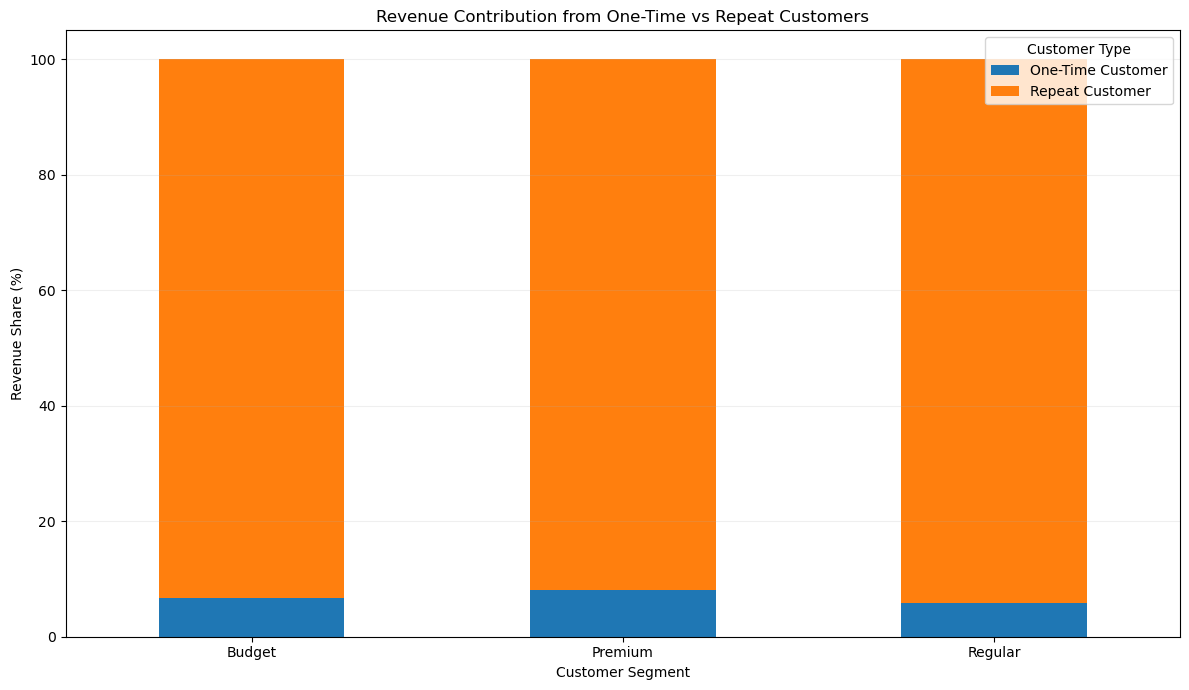

In [20]:
# ============================================================
# BUSINESS QUESTION 18
# What share of revenue comes from repeat customers versus
# first/one-time customers, and how does that split by segment?
#
# Chart:
# Revenue Mix — One-Time vs Repeat Customers by Segment
# ============================================================


# ------------------------------------------------------------
# Delivered orders only
# ------------------------------------------------------------

q18 = orders[
    [
        "order_id",
        "customer_id",
        "total_amount_eur",
        "order_status"
    ]
].copy()

q18["total_amount_eur"] = pd.to_numeric(
    q18["total_amount_eur"],
    errors="coerce"
)

q18 = q18[
    q18["order_status"].eq("Delivered")
].dropna(
    subset=["customer_id", "total_amount_eur"]
)

# ------------------------------------------------------------
# Count orders per customer
# ------------------------------------------------------------

customer_order_count = (
    q18
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count")
    )
    .reset_index()
)

customer_order_count["customer_type"] = (
    customer_order_count["total_orders"]
    .apply(
        lambda x:
        "Repeat Customer"
        if x > 1
        else "One-Time Customer"
    )
)

# ------------------------------------------------------------
# Add customer segment
# ------------------------------------------------------------

q18 = q18.merge(
    customers[
        [
            "customer_id",
            "customer_segment"
        ]
    ],
    on="customer_id",
    how="left"
)

q18 = q18.merge(
    customer_order_count,
    on="customer_id",
    how="left"
)

# ------------------------------------------------------------
# Revenue analysis
# ------------------------------------------------------------

revenue_summary = (
    q18
    .groupby(
        [
            "customer_segment",
            "customer_type"
        ]
    )
    .agg(
        revenue_eur=("total_amount_eur", "sum"),
        customers=("customer_id", "nunique"),
        orders=("order_id", "count")
    )
    .reset_index()
)

# Revenue share within each segment
revenue_summary["segment_total_revenue"] = (
    revenue_summary
    .groupby("customer_segment")["revenue_eur"]
    .transform("sum")
)

revenue_summary["revenue_share_pct"] = (
    revenue_summary["revenue_eur"]
    / revenue_summary["segment_total_revenue"]
) * 100

print(revenue_summary.round(2))


# ------------------------------------------------------------
# Overall revenue mix
# ------------------------------------------------------------

overall_mix = (
    q18
    .groupby("customer_type")
    ["total_amount_eur"]
    .sum()
    .reset_index()
)

overall_mix["revenue_share_pct"] = (
    overall_mix["total_amount_eur"]
    / overall_mix["total_amount_eur"].sum()
) * 100

print("\nOVERALL REVENUE MIX")
print(overall_mix.round(2))


# ============================================================
# CHART — Revenue Mix by Segment
# ============================================================

pivot18 = revenue_summary.pivot(
    index="customer_segment",
    columns="customer_type",
    values="revenue_share_pct"
)

ax = pivot18.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.title(
    "Revenue Contribution from One-Time vs Repeat Customers"
)

plt.xticks(rotation=0)

plt.legend(
    title="Customer Type"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

  employment_type  total_drivers  avg_speed_kmh  avg_driver_rating  \
0       Freelance             74          27.82               3.87   
1       Full-Time            136          28.38               3.81   
2       Part-Time            140          27.24               3.79   

   avg_completed_deliveries  
0                   1016.59  
1                    955.05  
2                    959.11  


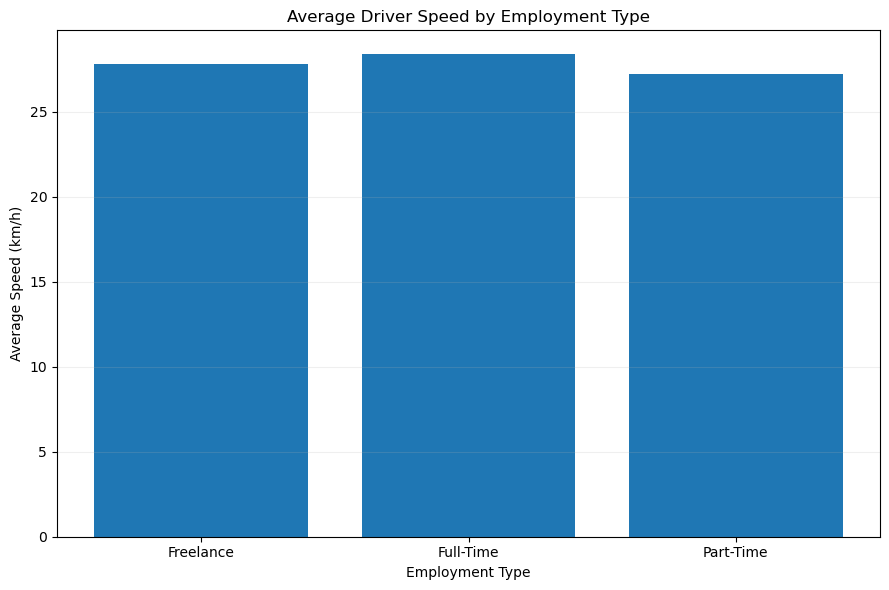

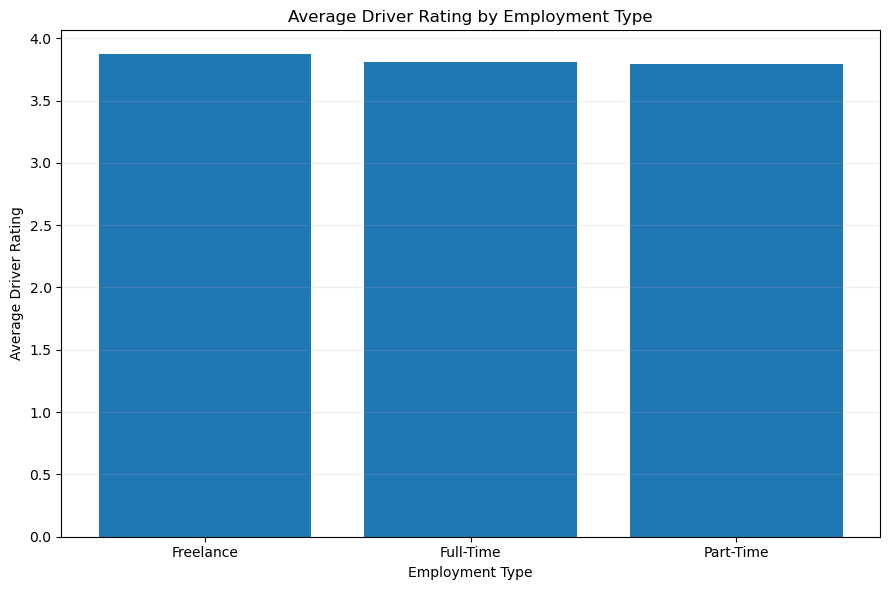

In [21]:
# ============================================================
# BUSINESS QUESTION 19
# Do freelance drivers perform differently from full-time
# drivers in terms of speed and ratings?
#
# Charts:
# 1. Average Driver Speed
# 2. Average Driver Rating
# ============================================================


# ------------------------------------------------------------
# Prepare driver data
# ------------------------------------------------------------

q19 = drivers[
    [
        "driver_id",
        "employment_type",
        "average_speed_kmh",
        "driver_rating",
        "completed_deliveries"
    ]
].copy()

q19["average_speed_kmh"] = pd.to_numeric(
    q19["average_speed_kmh"],
    errors="coerce"
)

q19["driver_rating"] = pd.to_numeric(
    q19["driver_rating"],
    errors="coerce"
)

q19["completed_deliveries"] = pd.to_numeric(
    q19["completed_deliveries"],
    errors="coerce"
)

q19 = q19.dropna(
    subset=[
        "employment_type",
        "average_speed_kmh",
        "driver_rating"
    ]
)

# ------------------------------------------------------------
# Driver performance summary
# ------------------------------------------------------------

driver_performance = (
    q19
    .groupby("employment_type")
    .agg(
        total_drivers=("driver_id", "nunique"),
        avg_speed_kmh=("average_speed_kmh", "mean"),
        avg_driver_rating=("driver_rating", "mean"),
        avg_completed_deliveries=(
            "completed_deliveries",
            "mean"
        )
    )
    .reset_index()
)

print(driver_performance.round(2))


# ============================================================
# CHART 1 — Average Speed
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    driver_performance["employment_type"],
    driver_performance["avg_speed_kmh"]
)

plt.xlabel("Employment Type")
plt.ylabel("Average Speed (km/h)")
plt.title(
    "Average Driver Speed by Employment Type"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — Average Driver Rating
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    driver_performance["employment_type"],
    driver_performance["avg_driver_rating"]
)

plt.xlabel("Employment Type")
plt.ylabel("Average Driver Rating")
plt.title(
    "Average Driver Rating by Employment Type"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

        country  total_reviews  avg_rating  avg_delivery_rating  \
2       Czechia             16        3.81                 4.19   
0       Austria             15        4.13                 4.20   
9   Netherlands             34        4.00                 4.26   
6       Germany             84        4.20                 4.30   
8         Italy             64        4.05                 4.33   
3       Denmark              9        4.22                 4.33   
7        Greece             24        4.08                 4.38   
14       Sweden             31        4.13                 4.39   
1       Belgium             28        4.21                 4.43   
5        France             51        4.18                 4.43   
13        Spain             45        3.98                 4.47   
11       Poland             39        4.33                 4.49   
4       Finland             20        3.95                 4.50   
12     Portugal             27        4.07                 4.5

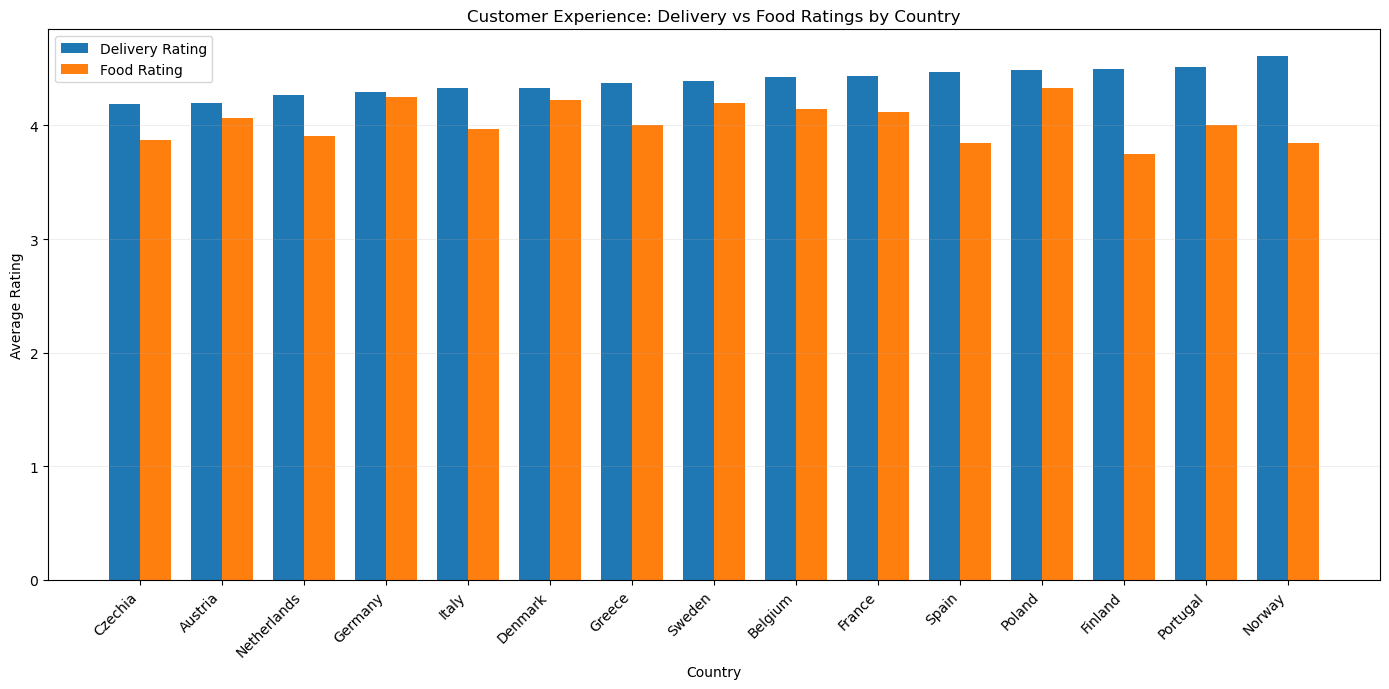

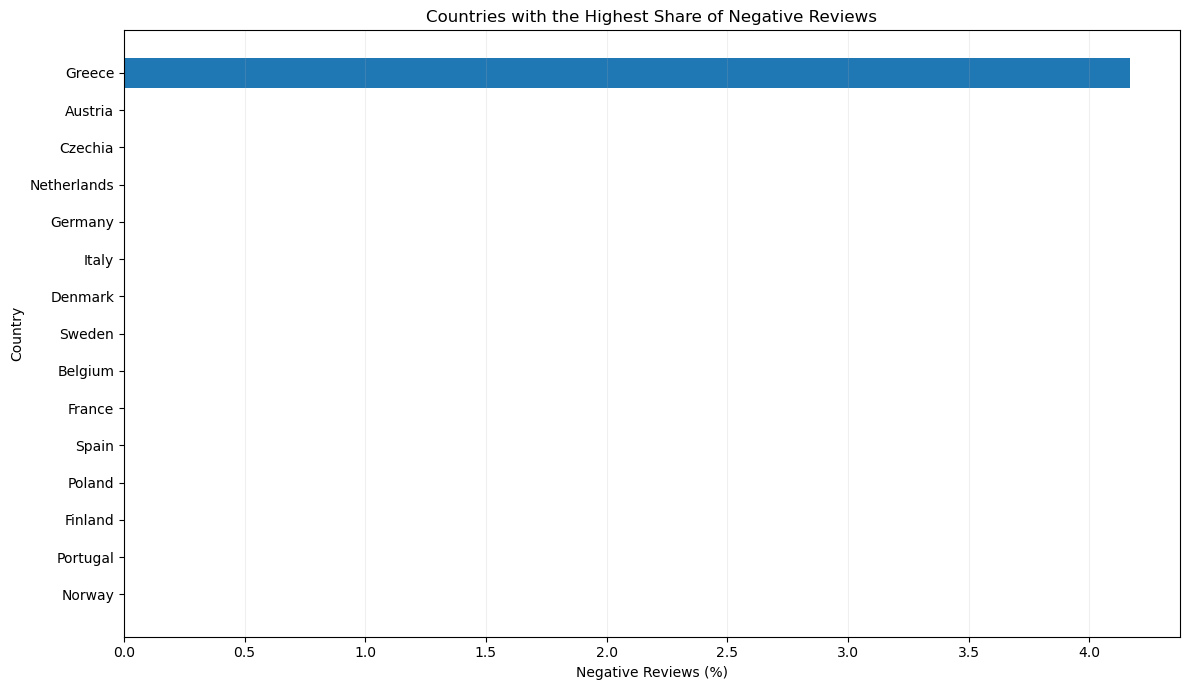

In [22]:
# ============================================================
# BUSINESS QUESTION 20
# Based on what customers say in reviews and how they rate
# their deliveries, where are the biggest pain points in
# their experience today?
#
# Charts:
# 1. Delivery vs Food Rating by Country
# 2. Negative Review Share by Country
# ============================================================


# ------------------------------------------------------------
# Prepare review dataset
# ------------------------------------------------------------

q20 = (
    reviews[
        [
            "review_id",
            "order_id",
            "rating",
            "delivery_rating",
            "food_rating",
            "review_sentiment"
        ]
    ]
    .merge(
        orders[
            [
                "order_id",
                "restaurant_id"
            ]
        ],
        on="order_id",
        how="left"
    )
    .merge(
        restaurants[
            [
                "restaurant_id",
                "country"
            ]
        ],
        on="restaurant_id",
        how="left"
    )
)

# Numeric conversion
for col in [
    "rating",
    "delivery_rating",
    "food_rating"
]:
    q20[col] = pd.to_numeric(
        q20[col],
        errors="coerce"
    )

q20 = q20.dropna(
    subset=[
        "country",
        "rating",
        "delivery_rating",
        "food_rating"
    ]
)

# ------------------------------------------------------------
# Standardize sentiment for analysis
# ------------------------------------------------------------

q20["review_sentiment_clean"] = (
    q20["review_sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Country-level experience
# ------------------------------------------------------------

country_experience = (
    q20
    .groupby("country")
    .agg(
        total_reviews=("review_id", "count"),
        avg_rating=("rating", "mean"),
        avg_delivery_rating=("delivery_rating", "mean"),
        avg_food_rating=("food_rating", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Negative review share
# ------------------------------------------------------------

negative_reviews = (
    q20
    .assign(
        negative_review=lambda x:
        x["review_sentiment_clean"].eq("negative")
    )
    .groupby("country")
    .agg(
        negative_review_share=(
            "negative_review",
            "mean"
        )
    )
    .reset_index()
)

negative_reviews["negative_review_share"] *= 100

country_experience = country_experience.merge(
    negative_reviews,
    on="country",
    how="left"
)

# Difference between food and delivery rating
country_experience["food_delivery_gap"] = (
    country_experience["avg_food_rating"]
    - country_experience["avg_delivery_rating"]
)

# Sort by delivery rating to identify delivery pain points
country_experience = country_experience.sort_values(
    "avg_delivery_rating"
)

print(
    country_experience.round(2)
)


# ============================================================
# CHART 1 — Delivery vs Food Rating
# ============================================================

chart20 = country_experience.copy()

x = range(len(chart20))
width = 0.38

plt.figure(figsize=(14, 7))

plt.bar(
    [i - width/2 for i in x],
    chart20["avg_delivery_rating"],
    width,
    label="Delivery Rating"
)

plt.bar(
    [i + width/2 for i in x],
    chart20["avg_food_rating"],
    width,
    label="Food Rating"
)

plt.xticks(
    list(x),
    chart20["country"],
    rotation=45,
    ha="right"
)

plt.xlabel("Country")
plt.ylabel("Average Rating")
plt.title(
    "Customer Experience: Delivery vs Food Ratings by Country"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# CHART 2 — Negative Review Share
# ============================================================

negative_chart = (
    country_experience
    .sort_values(
        "negative_review_share",
        ascending=False
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    negative_chart["country"],
    negative_chart["negative_review_share"]
)

plt.xlabel("Negative Reviews (%)")
plt.ylabel("Country")
plt.title(
    "Countries with the Highest Share of Negative Reviews"
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

###### ------------------------------------------------------------------------------------------------------------ THE END ------------------------------------------------------------------------------------------------------------